# 📈 Prophet Time-Series-Workflow – Peking Luftqualität (PRSA)
**Datensatz:** `PRSA_data_2010.1.1-2014.12.31.csv` – stündliche PM2.5-Messungen in Peking

Dieser Workflow implementiert einen robusten, 12-stufigen Ablauf:

1. **Daten laden** – CSV einlesen, `ds`/`y`-Format erzeugen
2. **Sichtprüfung** – Trend, Saisonalität, Ausreißer, Strukturbrüche?
3. **Datenaufbereitung** – Ausreißer → NaN setzen (Prophet verarbeitet NaNs nativ)
4. **Wachstumsmodell** – linear vs. logistic (+ Cap/Floor)
5. **Saisonalitätsmodus** – additiv vs. multiplikativ
6. **Features & Events** – `add_seasonality()`, Feiertage, externe Regressoren
7. **Modell fitten** – Prophet konfigurieren und trainieren
8. **Komponentenanalyse** – Zerlegung auf Plausibilität prüfen
9. **Cross-Validation & Tuning** – Grid Search über Prior-Scales
10. **Metriken auswerten** – MAE, RMSE, MAPE bewerten
11. **Residuenanalyse** – Systematische Muster aufspüren
12. **Prognose** – Forecast + Konfidenzintervall

### Datensatz-Überblick
| Merkmal | Wert |
|---------|------|
| Zeitraum | 01.01.2010 – 31.12.2014 |
| Frequenz | stündlich |
| Zielvariable | PM2.5 (µg/m³) |
| Weitere Spalten | DEWP, TEMP, PRES, cbwd, Iws, Is, Ir |
| Fehlwerte | ~13 % der PM2.5-Werte sind `NA` |

---

## 0 – Imports

In [18]:
# Abhängigkeiten installieren (nur beim ersten Mal nötig)
%pip install pandas matplotlib prophet --quiet

Note: you may need to restart the kernel to use updated packages.


In [19]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

plt.rcParams.update({"figure.figsize": (12, 4), "figure.dpi": 100})

---
## 1 – Daten laden

Der PRSA-Datensatz enthält stündliche Messungen. Die Spalten `year`, `month`, `day`, `hour`
werden zu einem Datetime-Index zusammengeführt. Als Zielvariable (`y`) wird **PM2.5** verwendet.

> `NA`-Werte in PM2.5 (~13 % der Daten) werden direkt als `NaN` übernommen.
> Prophet verarbeitet diese nativ – keine Interpolation nötig.

In [20]:
# ╔══════════════════════════════════════════════════════╗
# ║  DATENSATZ: PRSA – Peking Luftqualität (PM2.5)      ║
# ╚══════════════════════════════════════════════════════╝

DATENSATZ = "PRSA"

In [ ]:
def lade_datensatz(name: str) -> tuple[pd.DataFrame, str]:
    """
    Lädt den PRSA-Datensatz und gibt ein Prophet-kompatibles
    DataFrame (ds, y) sowie die Frequenz-Bezeichnung zurück.
    """
    if name == "PRSA":
        df_raw = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

        # Datetime aus einzelnen Zeitspalten zusammenbauen
        ds = pd.to_datetime(
            df_raw[["year", "month", "day", "hour"]].rename(
                columns={"year": "year", "month": "month", "day": "day", "hour": "hour"}
            )
        )

        # PM2.5 als Zielvariable; "NA"-Strings werden automatisch zu NaN
        y = pd.to_numeric(df_raw["pm2.5"], errors="coerce").values.astype(float)

        freq = "h"  # stündlich

    else:
        raise ValueError(f"Unbekannter Datensatz: {name}")

    df_prophet = pd.DataFrame({"ds": ds, "y": y})
    #for col in ["TEMP", "PRES", "DEWP", "Iws"]:
    #    df_prophet[col] = df_raw[col].values

    n_nan = df_prophet["y"].isna().sum()
    print(f"Datensatz:   {name}")
    print(f"Zeitraum:    {df_prophet['ds'].iloc[0]} bis {df_prophet['ds'].iloc[-1]}")
    print(f"Anzahl:      {len(df_prophet)} Beobachtungen")
    print(f"Frequenz:    {freq}")
    print(f"NaN in PM2.5: {n_nan} ({n_nan / len(df_prophet):.1%})")
    return df_prophet, freq


df_raw, FREQ = lade_datensatz(DATENSATZ)
df_raw.head(10)

Datensatz:   PRSA
Zeitraum:    2010-01-01 00:00:00 bis 2014-12-31 23:00:00
Anzahl:      43824 Beobachtungen
Frequenz:    h
NaN in PM2.5: 2067 (4.7%)


,ds,y,TEMP,PRES,DEWP,Iws
0,2010-01-01 00:00:00,NaN,-11.0,1021.0,-21,1.79
1,2010-01-01 01:00:00,NaN,-12.0,1020.0,-21,4.92
2,2010-01-01 02:00:00,NaN,-11.0,1019.0,-21,6.71
3,2010-01-01 03:00:00,NaN,-14.0,1019.0,-21,9.84
4,2010-01-01 04:00:00,NaN,-12.0,1018.0,-20,12.97
5,2010-01-01 05:00:00,NaN,-10.0,1017.0,-19,16.10
6,2010-01-01 06:00:00,NaN,-9.0,1017.0,-19,19.23
7,2010-01-01 07:00:00,NaN,-9.0,1017.0,-19,21.02
8,2010-01-01 08:00:00,NaN,-9.0,1017.0,-19,24.15
9,2010-01-01 09:00:00,NaN,-8.0,1017.0,-20,27.28


---
## 2 – Sichtprüfung

Vier Fragen für die visuelle Inspektion:

| Frage | Hinweise |
|-------|----------|
| **Trend?** | Steigend, fallend, abflachend? → Wachstumsmodell (Schritt 4) |
| **Saisonalität?** | Tages-, Wochen-, Jahreszyklus? |
| **Wachsende Amplitude?** | Schwankungen nehmen zu? → multiplikativer Modus (Schritt 5) |
| **Ausreißer / Strukturbrüche?** | Einzelne Spitzen, plötzliche Niveauänderung? → Schritt 3 |

> **Hinweis zu PM2.5:** Die Werte können extrem hohe Spitzen (>500 µg/m³) aufweisen
> (Smog-Episoden). Diese sind **echte Ereignisse**, keine Messfehler!

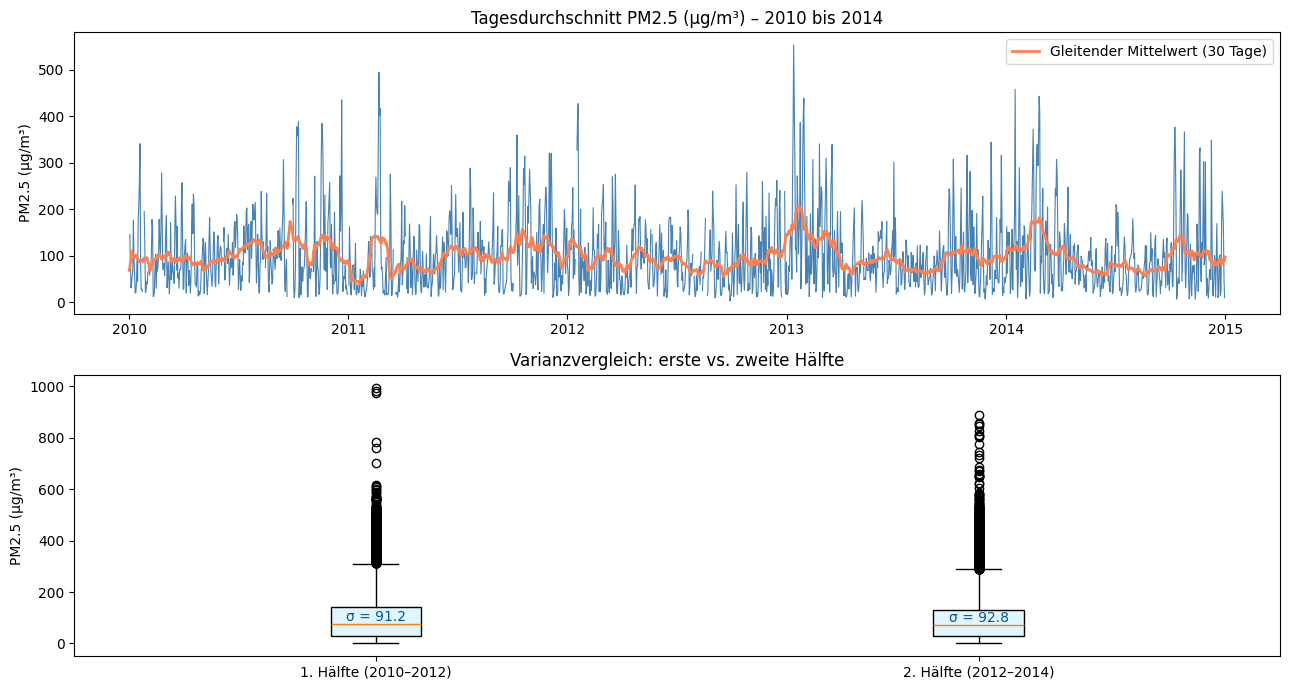


→ Prüfe:
  1. Zeigt PM2.5 einen langfristigen Trend?
     Kein klarer Trend → growth='linear' (Schritt 4)
  2. Ist σ in der 2. Hälfte deutlich größer als in der 1.?
     Ja → Schritt 5: seasonality_mode='multiplicative'
     Nein → Schritt 5: seasonality_mode='additive'


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# --- Rohdaten (Tagesdurchschnitt für bessere Lesbarkeit) ---
df_daily = df_raw.set_index("ds")["y"].resample("D").mean()
axes[0].plot(df_daily.index, df_daily.values, color="steelblue", linewidth=0.8)
axes[0].set_title("Tagesdurchschnitt PM2.5 (µg/m³) – 2010 bis 2014")
axes[0].set_ylabel("PM2.5 (µg/m³)")

# Gleitender 30-Tage-Mittelwert
fenster = 24 * 30  # 30 Tage in Stunden
rolling_mean = df_raw.set_index("ds")["y"].rolling(window=fenster, center=True, min_periods=1).mean()
axes[0].plot(rolling_mean.index, rolling_mean.values, color="coral",
             linewidth=2, label="Gleitender Mittelwert (30 Tage)")
axes[0].legend()

# --- Varianzvergleich erste vs. zweite Hälfte ---
halbzeit = len(df_raw) // 2
erste_haelfte = df_raw["y"].iloc[:halbzeit].dropna()
zweite_haelfte = df_raw["y"].iloc[halbzeit:].dropna()

axes[1].boxplot(
    [erste_haelfte, zweite_haelfte],
    tick_labels=["1. Hälfte (2010–2012)", "2. Hälfte (2012–2014)"],
    patch_artist=True,
    boxprops=dict(facecolor="#e1f5fe"),
)
axes[1].set_title("Varianzvergleich: erste vs. zweite Hälfte")
axes[1].set_ylabel("PM2.5 (µg/m³)")

for teil, x in [(erste_haelfte, 1), (zweite_haelfte, 2)]:
    axes[1].annotate(f"σ = {teil.std():.1f}", xy=(x, teil.median()),
                     fontsize=10, ha="center", va="bottom", color="#01579b")

plt.tight_layout()
plt.show()

print("\n→ Prüfe:")
print("  1. Zeigt PM2.5 einen langfristigen Trend?")
print("     Kein klarer Trend → growth='linear' (Schritt 4)")
print("  2. Ist σ in der 2. Hälfte deutlich größer als in der 1.?")
print("     Ja → Schritt 5: seasonality_mode='multiplicative'")
print("     Nein → Schritt 5: seasonality_mode='additive'")

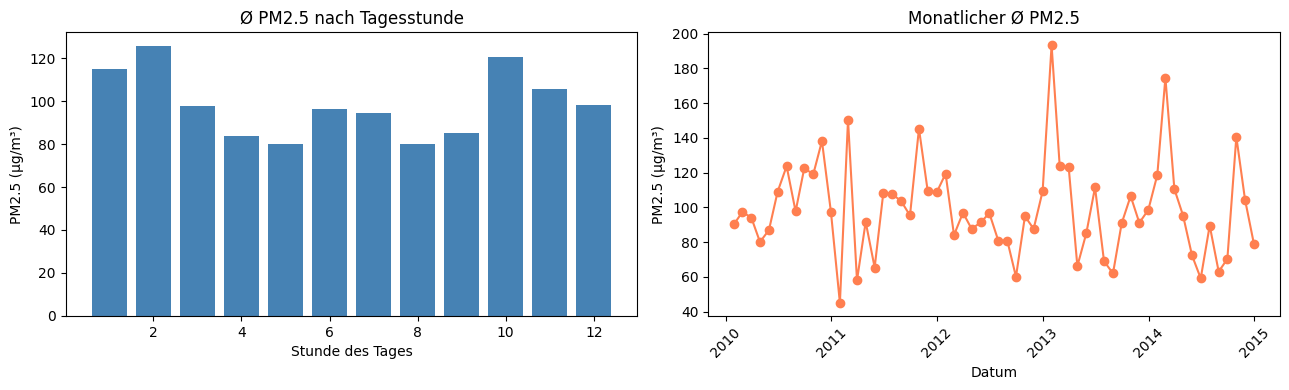

→ Saisonalitäten erkennbar: Tageszyklus (links) + Jahreszyklus (rechts, Winter = höher)


In [23]:
# --- Stündliche Saisonalität sichtbar machen (Durchschnitt pro Stunde des Tages) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tagesprofil
tagesprofil = df_raw.groupby(df_raw["ds"].dt.month)["y"].mean()
tagesprofil.index = tagesprofil.index % 24  # Modulo 24, um die Stunden zu normalisieren
tagesprofil = tagesprofil.sort_index()  # Sortiere die Stunden in der richtigen Reihenfolge
axes[0].bar(tagesprofil.index, tagesprofil.values, color="steelblue")
axes[0].set_title("Ø PM2.5 nach Tagesstunde")
axes[0].set_xlabel("Stunde des Tages")
axes[0].set_ylabel("PM2.5 (µg/m³)")

# Jahresprofil (Monatsdurchschnitt)
monatsprofil = df_raw.set_index("ds")["y"].resample("ME").mean()
axes[1].plot(monatsprofil.index, monatsprofil.values, "o-", color="coral")
axes[1].set_title("Monatlicher Ø PM2.5")
axes[1].set_xlabel("Datum")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("→ Saisonalitäten erkennbar: Tageszyklus (links) + Jahreszyklus (rechts, Winter = höher)")

---
## 3 – Datenaufbereitung

**Zwei Arten von fehlenden/problematischen Werten:**

1. **Strukturelle NaNs** (~13 %): `NA`-Werte in der Originaldatei – bereits als `NaN` eingelesen.
   Prophet überspringt diese nativ.

2. **Statistische Ausreißer** (> 3σ vom gleitenden Mittel): extreme Spikes,
   die die Changepoint-Erkennung verzerren könnten.

> **Achtung:** Bei PM2.5 können hohe Werte (>300 µg/m³) echte Smog-Ereignisse sein.
> Die Schwelle `SCHWELLE` sollte entsprechend großzügig gewählt werden (≥ 3.5σ).

Erkannte Ausreißer (>4.0σ): 35
→ 35 Werte auf NaN gesetzt.


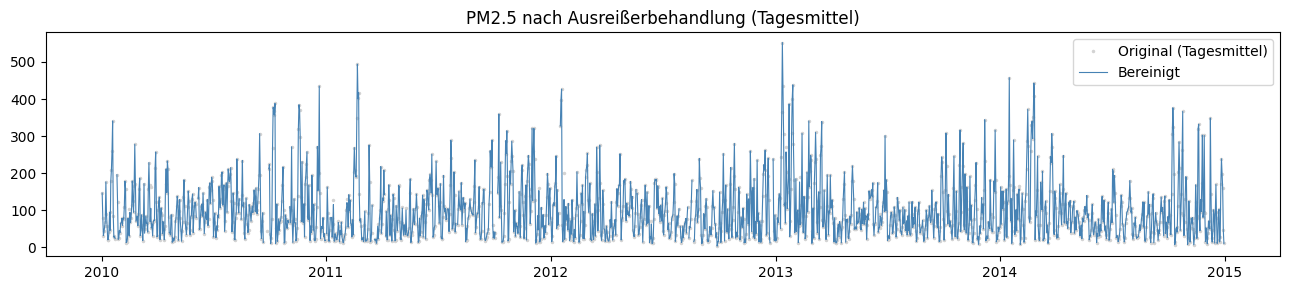


NaN-Werte gesamt: 2102 (4.8%) – von Prophet übersprungen


In [24]:
df = df_raw.copy()

# Fenster für gleitende Statistik: 7 Tage in Stunden
fenster = 24 * 7

# --- Ausreißer-Erkennung via gleitender Statistik ---
rolling = df.set_index("ds")["y"].rolling(window=fenster, center=True, min_periods=1)
rolling_mean = rolling.mean()
rolling_std = rolling.std()

# Erhöhte Schwelle wegen echter Smog-Spitzen
SCHWELLE = 4.0  # <-- bei Bedarf anpassen (≥ 3.5 empfohlen für PM2.5)

abweichung = (df.set_index("ds")["y"] - rolling_mean).abs()
ist_ausreisser = abweichung > SCHWELLE * rolling_std

n_ausreisser = ist_ausreisser.sum()
print(f"Erkannte Ausreißer (>{SCHWELLE}σ): {n_ausreisser}")

if n_ausreisser > 0:
    df.loc[ist_ausreisser.values, "y"] = np.nan
    print(f"→ {n_ausreisser} Werte auf NaN gesetzt.")

    fig, ax = plt.subplots(figsize=(13, 3))
    df_daily_raw = df_raw.set_index("ds")["y"].resample("D").mean()
    df_daily_clean = df.set_index("ds")["y"].resample("D").mean()
    ax.plot(df_daily_raw.index, df_daily_raw.values, ".", color="lightgray",
            label="Original (Tagesmittel)", markersize=3)
    ax.plot(df_daily_clean.index, df_daily_clean.values, color="steelblue",
            linewidth=0.8, label="Bereinigt")
    ax.set_title("PM2.5 nach Ausreißerbehandlung (Tagesmittel)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("→ Keine statistischen Ausreißer erkannt – Daten unverändert.")

print(f"\nNaN-Werte gesamt: {df['y'].isna().sum()} ({df['y'].isna().mean():.1%}) – von Prophet übersprungen")

---
## 4 – Wachstumsmodell wählen

| Modell | Wann geeignet? | Erfordert |
|--------|---------------|----------|
| `linear` | Trend steigt/fällt ohne erkennbare Sättigungsgrenze | nichts |
| `logistic` | Wachstum flacht ab, es gibt eine natürliche Obergrenze | `cap` (und optional `floor`) |

> **PM2.5-Datensatz:** Es gibt keine physikalische Obergrenze für PM2.5-Werte
> (theoretisch unbegrenzt). `linear` ist daher die geeignete Wahl.

In [25]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> WACHSTUMSMODELL WÄHLEN <<<                      ║
# ║  "linear"   → linearer Trend (Empfehlung für PM2.5) ║
# ║  "logistic" → begrenztes Wachstum (Cap/Floor nötig!) ║
# ╚══════════════════════════════════════════════════════╝

GROWTH = "linear"  # <-- Empfehlung für PM2.5

if GROWTH == "logistic":
    CAP = df["y"].max() * 1.2
    FLOOR = 0
    df["cap"] = CAP
    df["floor"] = FLOOR
    print(f"Logistic Growth: Cap = {CAP:.1f}, Floor = {FLOOR:.1f}")
else:
    print("Linear Growth – keine Sättigungsgrenzen nötig.")

print(f"\n★ Wachstumsmodell: {GROWTH}")

Linear Growth – keine Sättigungsgrenzen nötig.

★ Wachstumsmodell: linear


---
## 5 – Saisonalitätsmodus wählen

| Modus | Bedeutung | Wann? |
|-------|-----------|-------|
| `additive` | Saisonale Schwankung ist **konstant** in absoluten Werten | Amplitude bleibt über die Zeit gleich |
| `multiplicative` | Saisonale Schwankung ist **proportional** zum Trend | Amplitude wächst mit dem Niveau |

> **PM2.5-Datensatz:** Die Amplitude der Schwankungen korreliert stark mit dem Niveau
> (hohe Basiswerte → höhere absolute Ausschläge). Daher: `multiplicative`.

In [26]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> SAISONALITÄTSMODUS WÄHLEN <<<                   ║
# ║  "additive"       → konstante Schwankungsbreite      ║
# ║  "multiplicative" → wachsende Schwankungsbreite      ║
# ║  Empfehlung für PM2.5: "multiplicative"              ║
# ╚══════════════════════════════════════════════════════╝

SEASONALITY_MODE = "multiplicative"  # <-- Empfehlung für PM2.5

print(f"★ Saisonalitätsmodus: {SEASONALITY_MODE}")

★ Saisonalitätsmodus: multiplicative


---
## 6 – Features & Events

Für den PRSA-Datensatz bieten sich folgende Erweiterungen an:

| Mechanismus | API | Wann einsetzen? |
|-------------|-----|----------------|
| **Zusätzliche Saisonalität** | `add_seasonality(name, period, fourier_order)` | Wochenzyklus bei Stundendaten |
| **Feiertage / Events** | `holidays`-DataFrame | Chinesisches Neujahr (starke PM2.5-Spitzen durch Feuerwerk!) |
| **Externe Regressoren** | `add_regressor(name)` | TEMP, PRES, DEWP, Windgeschwindigkeit (Iws) |

> **Beim ersten Durchlauf leer lassen.** Nach Schritt 11 (Residuenanalyse)
> hierhin zurückkehren und gezielte Ergänzungen vornehmen.
>
> **Tipp:** Das Chinesische Neujahr (Jan/Feb) verursacht starke PM2.5-Spitzen
> durch Feuerwerk – ein guter Kandidat für `holidays`.

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> FEATURES & EVENTS DEFINIEREN (optional) <<<     ║
# ║  Beim ersten Durchlauf: leer lassen.                 ║
# ║  Nach Schritt 11 (Residuen): hier ergänzen.          ║
# ╚══════════════════════════════════════════════════════╝

# --- Zusätzliche Saisonalitäten ---
# Wochenzyklus (Prophet erkennt daily/weekly/yearly automatisch bei Stundendaten)
# Beispiel für manuelle Ergänzung:
# EXTRA_SEASONALITIES = [
#     {"name": "wochentag", "period": 7, "fourier_order": 3},
# ]

EXTRA_SEASONALITIES = []  # <-- bei Bedarf ergänzen

# --- Feiertage / Events ---
# Chinesisches Neujahr: starke PM2.5-Spitzen durch Feuerwerk
# Beispiel:
# feiertage = pd.DataFrame({
#     "holiday": "chinesisches_neujahr",
#     "ds": pd.to_datetime(["2010-02-14", "2011-02-03", "2012-01-23",
#                           "2013-02-10", "2014-01-31"]),
#     "lower_window": -1,
#     "upper_window": 3,
# })

feiertage = None  # <-- auf DataFrame setzen, wenn gewünscht

# --- Externe Regressoren ---
# Mögliche Kandidaten: "TEMP", "PRES", "DEWP", "Iws"
# Achtung: Diese Spalten müssen dann aus df_raw in df übernommen und
# auch für das future-DataFrame bereitgestellt werden.

EXTRA_REGRESSORS = []  # <-- z. B. ["TEMP", "Iws"]
#EXTRA_REGRESSORS = ["TEMP", "PRES", "DEWP", "Iws"]

print("Konfigurierte Features:")
print(f"  Zusätzliche Saisonalitäten: {len(EXTRA_SEASONALITIES)}")
print(f"  Feiertage:                  {'definiert' if feiertage is not None else 'keine'}")
print(f"  Externe Regressoren:        {len(EXTRA_REGRESSORS)}")

Konfigurierte Features:
  Zusätzliche Saisonalitäten: 0
  Feiertage:                  keine
  Externe Regressoren:        4


---
## 7 – Modell fitten

| Parameter | Wirkung | Default |
|-----------|---------|--------|
| `changepoint_prior_scale` | Flexibilität des Trends | 0.05 |
| `seasonality_prior_scale` | Stärke der Saisonalität | 10 |
| `n_changepoints` | Anzahl potentieller Trendänderungspunkte | 25 |

> Bei stündlichen Daten über 5 Jahre aktiviert Prophet automatisch
> `daily_seasonality`, `weekly_seasonality` und `yearly_seasonality`.

In [28]:
N_CHANGEPOINTS = 25  # <-- bei Bedarf anpassen


def baue_modell(chg_prior: float = 0.05,
                sea_prior: float = 10.0) -> Prophet:
    """
    Baut ein Prophet-Modell mit den gewählten Strukturparametern
    (aus Schritt 4–6) und den übergebenen Prior-Scales.
    """
    m = Prophet(
        growth=GROWTH,
        seasonality_mode=SEASONALITY_MODE,
        changepoint_prior_scale=chg_prior,
        seasonality_prior_scale=sea_prior,
        n_changepoints=N_CHANGEPOINTS,
        holidays=feiertage,
        yearly_seasonality="auto",
        weekly_seasonality="auto",
        daily_seasonality="auto",
    )

    for s in EXTRA_SEASONALITIES:
        m.add_seasonality(**s)

    for reg in EXTRA_REGRESSORS:
        m.add_regressor(reg)

    return m


# --- Erster Fit mit Defaults ---
modell = baue_modell()
modell.fit(df)

print(f"★ Modell gefittet (Default-Priors):")
print(f"  growth                  = {GROWTH}")
print(f"  seasonality_mode        = {SEASONALITY_MODE}")
print(f"  changepoint_prior_scale = 0.05 (Default)")
print(f"  seasonality_prior_scale = 10.0 (Default)")
print(f"  n_changepoints          = {N_CHANGEPOINTS}")
print(f"  Feiertage:              {'ja' if feiertage is not None else 'nein'}")

★ Modell gefittet (Default-Priors):
  growth                  = linear
  seasonality_mode        = multiplicative
  changepoint_prior_scale = 0.05 (Default)
  seasonality_prior_scale = 10.0 (Default)
  n_changepoints          = 25
  Feiertage:              nein


---
## 8 – Komponentenanalyse

`plot_components()` zerlegt die Zeitreihe in ihre Bestandteile.

> **Erwartete Komponenten bei PM2.5:**
> - **Trend:** schwacher oder kein Trend über 5 Jahre
> - **Jahreszyklus:** Winter-Peak (Dezember–Februar) durch Heizung + ungünstige Wetterlage
> - **Wochenzyklus:** Wochentag-Effekte (Verkehr, Industrie)
> - **Tageszyklus:** Morgen- und Abendspitzen (Rush-Hour)

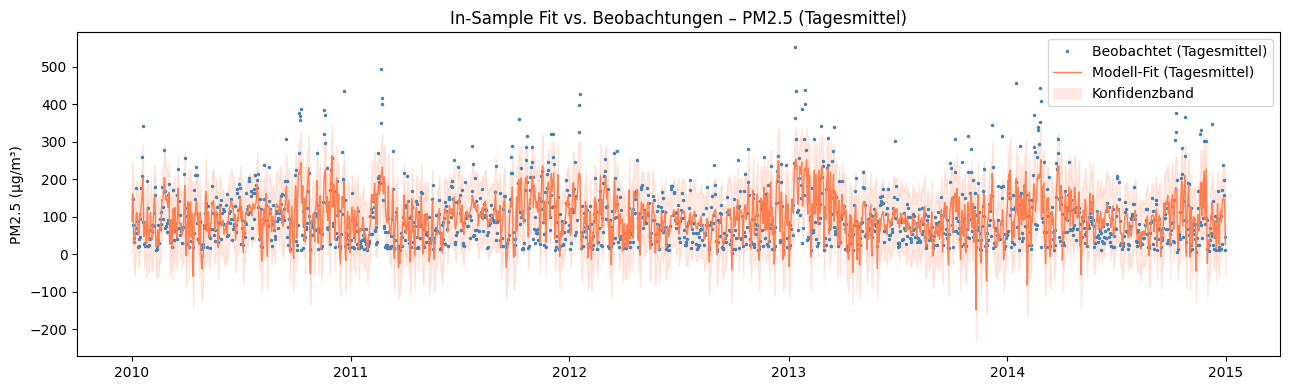

In [29]:
# In-Sample-Vorhersage (Stichproben-Plot für Lesbarkeit)
df_pred = modell.predict(df)

# --- Fit vs. Beobachtung (Tagesmittel für Lesbarkeit) ---
fig, ax = plt.subplots(figsize=(13, 4))

df_obs_daily = df.set_index("ds")["y"].resample("D").mean()
df_fit_daily = df_pred.set_index("ds")["yhat"].resample("D").mean()
df_lower_daily = df_pred.set_index("ds")["yhat_lower"].resample("D").mean()
df_upper_daily = df_pred.set_index("ds")["yhat_upper"].resample("D").mean()

ax.plot(df_obs_daily.index, df_obs_daily.values, ".", color="steelblue",
        markersize=3, label="Beobachtet (Tagesmittel)")
ax.plot(df_fit_daily.index, df_fit_daily.values, color="coral",
        linewidth=1, label="Modell-Fit (Tagesmittel)")
ax.fill_between(df_lower_daily.index, df_lower_daily.values, df_upper_daily.values,
                color="coral", alpha=0.15, label="Konfidenzband")
ax.set_title("In-Sample Fit vs. Beobachtungen – PM2.5 (Tagesmittel)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

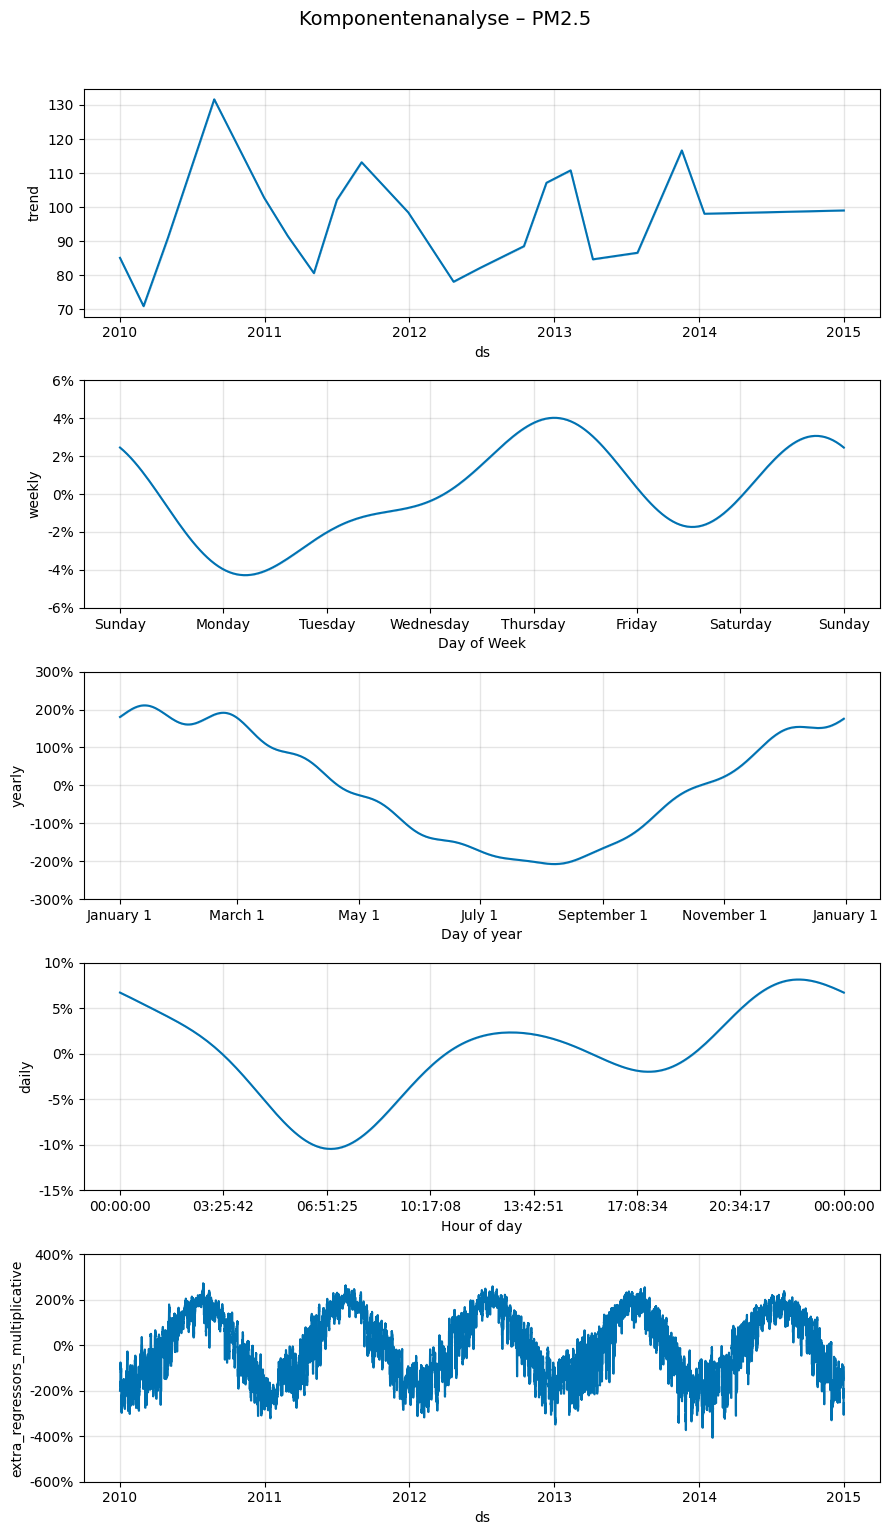

→ Prüfe:
  - Trend: Schwacher oder kein Trend über 5 Jahre?
  - Jahreszyklus: Winter-Peak (Dez–Feb) durch Heizungseffekte?
  - Tageszyklus: Morgen/Abend-Spitzen (Rush-Hour)?
  - Wochenzyklus: Wochenende vs. Werktag?


In [30]:
# --- Komponentenzerlegung ---
fig = modell.plot_components(df_pred)
plt.suptitle("Komponentenanalyse – PM2.5", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("→ Prüfe:")
print("  - Trend: Schwacher oder kein Trend über 5 Jahre?")
print("  - Jahreszyklus: Winter-Peak (Dez–Feb) durch Heizungseffekte?")
print("  - Tageszyklus: Morgen/Abend-Spitzen (Rush-Hour)?")
print("  - Wochenzyklus: Wochenende vs. Werktag?")

---
## 9 – Cross-Validation & Hyperparameter-Tuning

| Parameter | Wirkung | Suchbereich |
|-----------|---------|-------------|
| `changepoint_prior_scale` | Trend-Flexibilität | 0.01 – 0.5 |
| `seasonality_prior_scale` | Saisonalitäts-Stärke | 0.1 – 10 |

> **CV-Fenster für 5 Jahre Stundendaten:**
> - `initial = "730 days"` (2 Jahre Trainingsdaten)
> - `period = "90 days"` (Abstand zwischen Folds)
> - `horizon = "30 days"` (1 Monat Prognosehorizont)

In [31]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> PARAMETER-TUNING für PRSA <<<                   ║
# ║  Angepasste CV-Parameter für 5 Jahre Stundendaten    ║
# ╚══════════════════════════════════════════════════════╝

param_combinations = [
    (0.05, 10.0),   # Prophet-Default
    (0.1,  10.0),   # Flexiblerer Trend
    (0.05,  1.0),   # Schwächere Saisonalität
]

# CV-Parameter angepasst für 5 Jahre Stundendaten
cv_params = {
    "initial": "730 days",   # 2 Jahre Trainingsdaten
    "period":  "90 days",    # Abstand zwischen Folds
    "horizon": "30 days",    # 1 Monat Prognosehorizont
}

print(f"Tuning: {len(param_combinations)} Kombinationen")
print(f"CV-Parameter: {cv_params}")
print(f"Hinweis: Bei stündlichen Daten kann jeder Fold mehrere Minuten dauern.\n")
print(f"{'Nr':>2s}  {'chg_prior':>8s}  {'sea_prior':>8s}  {'MAPE':>7s}  {'RMSE':>8s}")
print("-" * 48)

ergebnisse_grid = []
df_cv = None

for i, (chg, sea) in enumerate(param_combinations, 1):
    m_candidate = baue_modell(chg_prior=chg, sea_prior=sea)
    m_candidate.fit(df)

    try:
        df_cv_i = cross_validation(m_candidate, **cv_params, disable_tqdm=True)

        valid = df_cv_i[["y", "yhat"]].dropna()
        if len(valid) == 0:
            continue

        errors = valid["y"] - valid["yhat"]
        rmse_i = (errors ** 2).mean() ** 0.5
        mape_i = (errors.abs() / valid["y"].abs()).mean()

    except Exception as e:
        print(f"  Kombination {i} übersprungen: {e}")
        continue

    ergebnisse_grid.append({
        "changepoint_prior_scale": chg,
        "seasonality_prior_scale": sea,
        "mape": mape_i,
        "rmse": rmse_i,
        "cv_detail": df_cv_i,
    })
    print(f"{i:2d}  {chg:8.3f}  {sea:8.1f}  {mape_i:>6.2%}  {rmse_i:>8.2f}")

# --- Bestes Modell auswählen ---
if not ergebnisse_grid:
    print("\n⚠️  Tuning fehlgeschlagen. Verwende Default-Werte.")
    CHANGEPOINT_PRIOR = 0.05
    SEASONALITY_PRIOR = 10.0
else:
    beste = min(ergebnisse_grid, key=lambda x: x["mape"])
    CHANGEPOINT_PRIOR = beste["changepoint_prior_scale"]
    SEASONALITY_PRIOR = beste["seasonality_prior_scale"]
    df_cv = beste["cv_detail"]

    print(f"\n★ Beste Kombination:")
    print(f"  changepoint_prior_scale = {CHANGEPOINT_PRIOR}")
    print(f"  seasonality_prior_scale = {SEASONALITY_PRIOR}")
    print(f"  MAPE = {beste['mape']:.2%}, RMSE = {beste['rmse']:.2f} µg/m³")

modell = baue_modell(chg_prior=CHANGEPOINT_PRIOR, sea_prior=SEASONALITY_PRIOR)
modell.fit(df)
print(f"\n✔ Modell nachgefittet – bereit für Schritt 10.")

Tuning: 3 Kombinationen
CV-Parameter: {'initial': '730 days', 'period': '90 days', 'horizon': '30 days'}
Hinweis: Bei stündlichen Daten kann jeder Fold mehrere Minuten dauern.

Nr  chg_prior  sea_prior     MAPE      RMSE
------------------------------------------------
 1     0.050      10.0    inf%     80.05
 2     0.100      10.0    inf%     81.52
 3     0.050       1.0    inf%     80.03

★ Beste Kombination:
  changepoint_prior_scale = 0.05
  seasonality_prior_scale = 10.0
  MAPE = inf%, RMSE = 80.05 µg/m³

✔ Modell nachgefittet – bereit für Schritt 10.


---
## 10 – Metriken auswerten

| Metrik | Interpretation |
|--------|---------------|
| **MAE** | Mittlerer absoluter Fehler in µg/m³ |
| **RMSE** | Bestraft große Fehler stärker als MAE |
| **MAPE** | Prozentualer Fehler – gut zum Vergleich |

> **Orientierungswerte für PM2.5-Prognosen:**
> - MAPE < 30 %: akzeptabel (PM2.5 ist schwer vorherzusagen)
> - MAPE < 20 %: gut
> - MAPE < 10 %: sehr gut

Durchschnittliche Metriken über alle CV-Folds:
  MAE  = 58.10 µg/m³
  RMSE = 78.31 µg/m³
  MAPE = 148.39% (manuell berechnet, nur y>0-Werte)
  Hinweis: 'mape' fehlt in performance_metrics (PM2.5=0 im CV-Set)


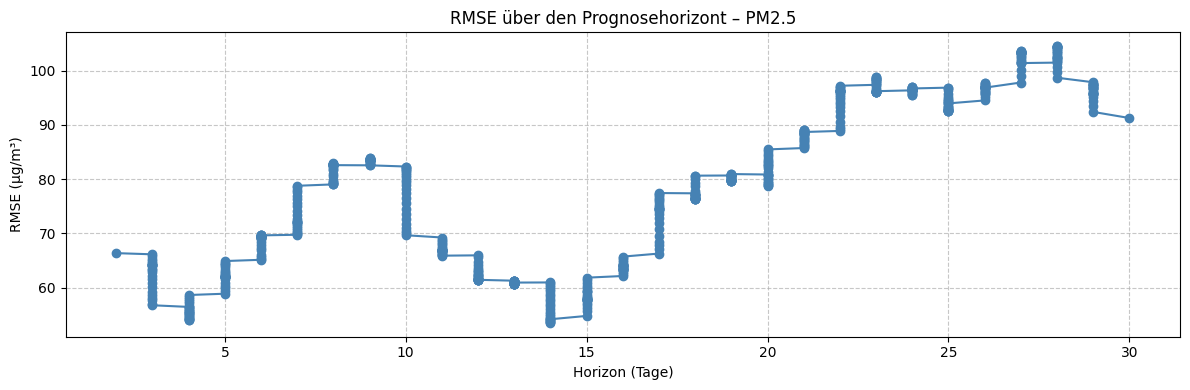


✗ MAPE > 30 % – Modellstruktur überdenken!
  → Schritt 5: Saisonalitätsmodus wechseln
  → Schritt 6: Externe Regressoren ergänzen


In [32]:
def berechne_mape_manuell(df_cv_data: pd.DataFrame) -> float:
    """Berechnet MAPE manuell aus CV-Daten, filtert y=0 heraus."""
    valid = df_cv_data[["y", "yhat"]].dropna()
    valid = valid[valid["y"] > 0]  # Division durch Null vermeiden
    if len(valid) == 0:
        return float("nan")
    return ((valid["y"] - valid["yhat"]).abs() / valid["y"]).mean()


if df_cv is not None:
    df_metrics = performance_metrics(df_cv)
    print("Durchschnittliche Metriken über alle CV-Folds:")
    print(f"  MAE  = {df_metrics['mae'].mean():.2f} µg/m³")
    print(f"  RMSE = {df_metrics['rmse'].mean():.2f} µg/m³")

    # MAPE: Prophet lässt die Spalte weg, wenn y=0-Werte im CV-Set vorkommen
    if "mape" in df_metrics.columns:
        mape_value = df_metrics["mape"].mean()
        plot_metric = "mape"
        print(f"  MAPE = {mape_value:.2%}")
    else:
        mape_value = berechne_mape_manuell(df_cv)
        plot_metric = "rmse"
        print(f"  MAPE = {mape_value:.2%} (manuell berechnet, nur y>0-Werte)")
        print("  Hinweis: 'mape' fehlt in performance_metrics (PM2.5=0 im CV-Set)")

    plt.figure(figsize=(12, 4))
    plt.plot(df_metrics["horizon"].dt.days, df_metrics[plot_metric], "o-", color="steelblue")
    plt.title(f"{plot_metric.upper()} über den Prognosehorizont – PM2.5")
    plt.xlabel("Horizon (Tage)")
    plt.ylabel(plot_metric.upper() + (" (µg/m³)" if plot_metric == "rmse" else ""))
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("\n⚠️  Keine Cross-Validation – berechne In-Sample-Metriken.")
    df_pred_full = modell.predict(df)
    mask = ~np.isnan(df["y"].values) & (df["y"].values > 0)
    y_true = df["y"].values[mask]
    y_pred = df_pred_full["yhat"].values[mask]
    errors = y_true - y_pred
    mae = np.abs(errors).mean()
    rmse = (errors ** 2).mean() ** 0.5
    mape_value = (np.abs(errors) / y_true).mean()
    print(f"  MAE  = {mae:.2f} µg/m³")
    print(f"  RMSE = {rmse:.2f} µg/m³")
    print(f"  MAPE = {mape_value:.2%}")

# Bewertung mit PM2.5-angepassten Schwellenwerten
if np.isnan(mape_value):
    print("\n⚠️  MAPE konnte nicht berechnet werden.")
elif mape_value < 0.10:
    print("\n✔ MAPE < 10 % – sehr gute Prognosegüte für PM2.5.")
elif mape_value < 0.20:
    print("\n✔ MAPE 10–20 % – gute Prognosegüte für PM2.5.")
elif mape_value < 0.30:
    print("\n◐ MAPE 20–30 % – akzeptabel. Falls Verbesserung gewünscht:")
    print("  → Schritt 6: Chinesisches Neujahr als Feiertag ergänzen")
    print("  → Schritt 6: Wettervariablen als Regressoren (TEMP, Iws)")
else:
    print("\n✗ MAPE > 30 % – Modellstruktur überdenken!")
    print("  → Schritt 5: Saisonalitätsmodus wechseln")
    print("  → Schritt 6: Externe Regressoren ergänzen")

---
## 11 – Residuenanalyse

| Befund | Mögliche Ursache | Maßnahme |
|--------|-----------------|----------|
| Wiederkehrendes Muster | Fehlende Saisonalität | `add_seasonality()` in Schritt 6 |
| Autokorrelation | Saisonale Ordnung zu niedrig | `fourier_order` erhöhen |
| Einzelne große Ausreißer | Chinesisches Neujahr / Smog-Episoden | Feiertage in Schritt 6 ergänzen |
| Systematischer Bias | Trend-Fehlspezifikation | Wachstumsmodell überprüfen |

> **Residuen werden aus stündlichen Daten berechnet, aber als Tagesmittel visualisiert**
> für bessere Lesbarkeit.

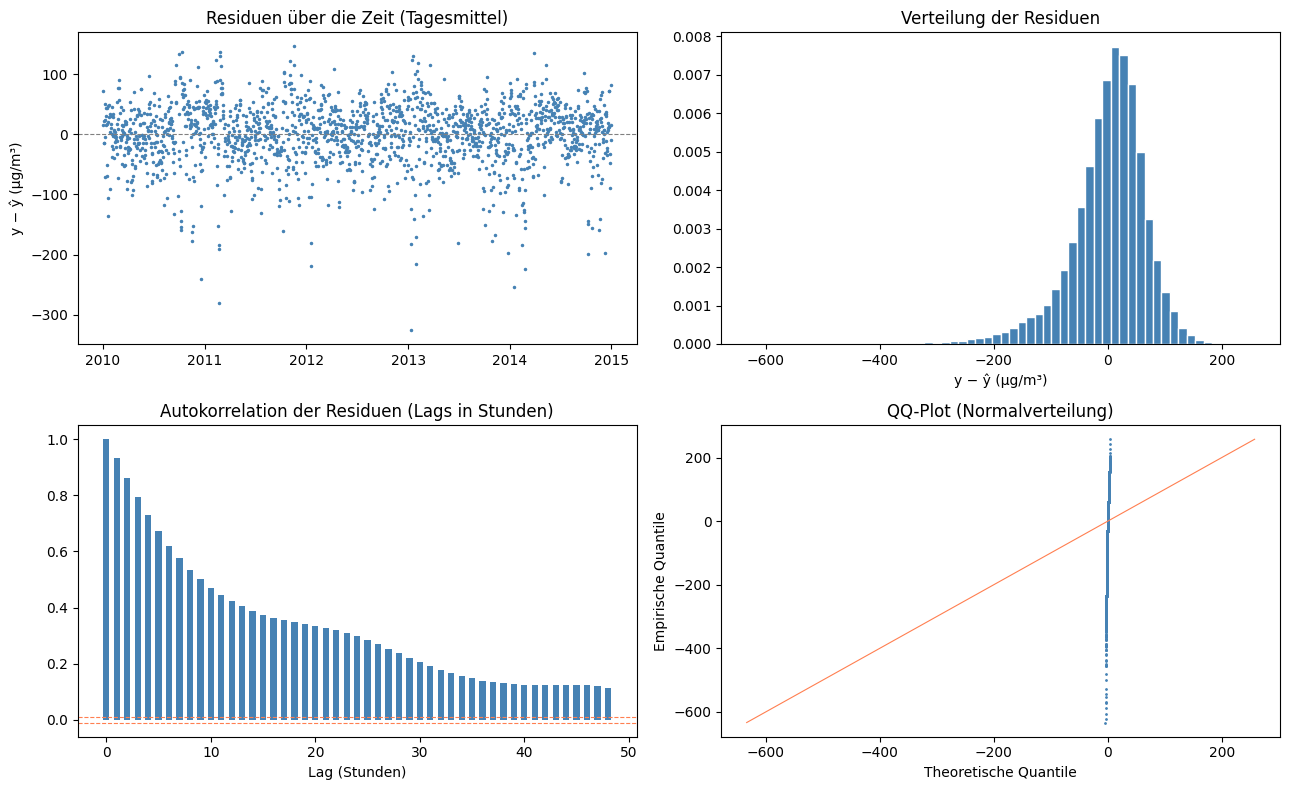

Signifikante Autokorrelationen: 48 von 48 Lags

✗ 48 signifikante Lags – systematisches Muster!
  → Zurück zu Schritt 6: Externe Regressoren oder Feiertage ergänzen.
  → Dann ab Schritt 6 erneut ausführen (6 → 7 → 8 → 9 → 10 → 11).


In [33]:
# --- Residuen berechnen ---
df_pred = modell.predict(df)
residuen = df_pred.set_index("ds")["yhat"].reindex(df["ds"]).values - df["y"].values

maske_valid = ~np.isnan(residuen) & ~np.isnan(df["y"].values)
residuen_clean = residuen[maske_valid]
ds_clean = df["ds"].values[maske_valid]

# Für die Autokorrelation: Fenster = 24 Lags (1 Tag)
max_lag = 48  # 2 Tage

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1) Residuen über die Zeit (Tagesmittel)
res_series = pd.Series(residuen_clean, index=pd.DatetimeIndex(ds_clean))
res_daily = res_series.resample("D").mean()
axes[0, 0].plot(res_daily.index, res_daily.values, ".", color="steelblue", markersize=3)
axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0, 0].set_title("Residuen über die Zeit (Tagesmittel)")
axes[0, 0].set_ylabel("y − ŷ (µg/m³)")

# 2) Histogramm der Residuen
axes[0, 1].hist(residuen_clean, bins=60, color="steelblue", edgecolor="white", density=True)
axes[0, 1].set_title("Verteilung der Residuen")
axes[0, 1].set_xlabel("y − ŷ (µg/m³)")

# 3) Autokorrelation der Residuen (stündlich)
r_mean = residuen_clean.mean()
r_var = np.sum((residuen_clean - r_mean) ** 2)
acf_vals = []
for lag in range(max_lag + 1):
    if lag == 0:
        acf_vals.append(1.0)
    else:
        cov = np.sum((residuen_clean[lag:] - r_mean) * (residuen_clean[:-lag] - r_mean))
        acf_vals.append(cov / r_var)

axes[1, 0].bar(range(max_lag + 1), acf_vals, color="steelblue", width=0.6)
konf_grenze = 1.96 / np.sqrt(len(residuen_clean))
axes[1, 0].axhline(konf_grenze, color="coral", linestyle="--", linewidth=0.8)
axes[1, 0].axhline(-konf_grenze, color="coral", linestyle="--", linewidth=0.8)
axes[1, 0].set_title("Autokorrelation der Residuen (Lags in Stunden)")
axes[1, 0].set_xlabel("Lag (Stunden)")

# 4) QQ-Plot
from scipy.stats import norm
sorted_res = np.sort(residuen_clean)
n = len(sorted_res)
theoretical_q = norm.ppf((np.arange(1, n + 1) - 0.5) / n)
axes[1, 1].scatter(theoretical_q, sorted_res, s=1, color="steelblue")
lims = [min(theoretical_q.min(), sorted_res.min()), max(theoretical_q.max(), sorted_res.max())]
axes[1, 1].plot(lims, lims, color="coral", linewidth=0.8)
axes[1, 1].set_title("QQ-Plot (Normalverteilung)")
axes[1, 1].set_xlabel("Theoretische Quantile")
axes[1, 1].set_ylabel("Empirische Quantile")

plt.tight_layout()
plt.show()

n_signifikant = sum(1 for v in acf_vals[1:] if abs(v) > konf_grenze)
print(f"Signifikante Autokorrelationen: {n_signifikant} von {max_lag} Lags")

if n_signifikant <= 3:
    print("\n✔ Residuen zeigen kein auffälliges Muster – Modell gut spezifiziert.")
else:
    print(f"\n✗ {n_signifikant} signifikante Lags – systematisches Muster!")
    print("  → Zurück zu Schritt 6: Externe Regressoren oder Feiertage ergänzen.")
    print("  → Dann ab Schritt 6 erneut ausführen (6 → 7 → 8 → 9 → 10 → 11).")

---
## 12 – Prognose

Wenn Metriken und Residuen zufriedenstellend sind, wird die finale
Prognose für die nächsten **7 Tage** (168 Stunden) erstellt.

  TEMP: 168 Zukunftswerte mit saisonalem Mittel aufgefüllt
  PRES: 168 Zukunftswerte mit saisonalem Mittel aufgefüllt
  DEWP: 168 Zukunftswerte mit saisonalem Mittel aufgefüllt
  Iws: 168 Zukunftswerte mit saisonalem Mittel aufgefüllt
★ 4 Regressoren im future-DataFrame gesetzt.


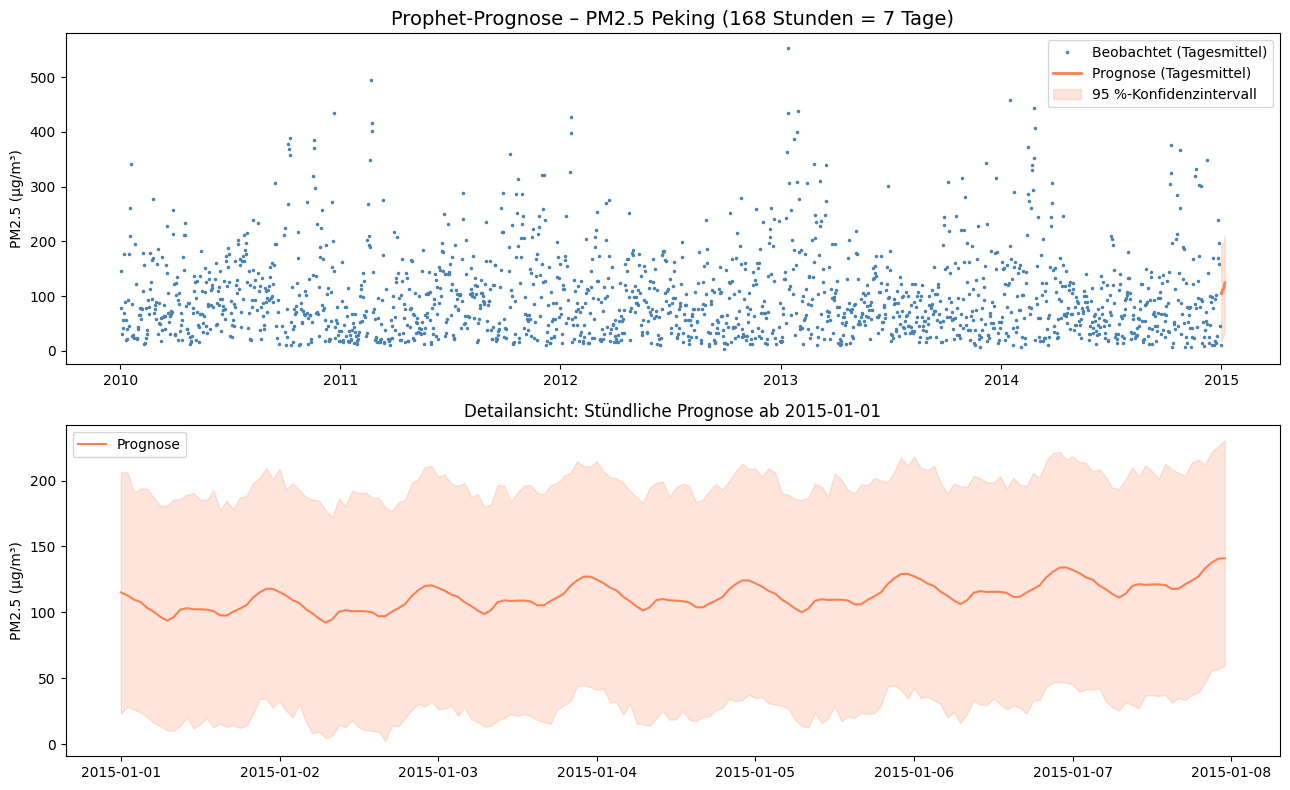


Prognose – Tagesmittel für 7 Tage ab 2015-01-01:
            Prognose  Untergrenze  Obergrenze
ds                                           
2015-01-01     104.8         19.0       190.9
2015-01-02     104.4         17.1       190.0
2015-01-03     111.2         24.7       196.6
2015-01-04     112.0         25.9       197.3
2015-01-05     112.7         26.8       198.5
2015-01-06     118.4         32.3       204.2
2015-01-07     124.0         38.7       209.9


In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> PROGNOSEHORIZONT EINSTELLEN <<<                 ║
# ╚══════════════════════════════════════════════════════╝

HORIZONT = 168  # Stunden = 7 Tage  <-- bei Bedarf anpassen

future = modell.make_future_dataframe(periods=HORIZONT, freq=FREQ)

if GROWTH == "logistic":
    future["cap"] = CAP
    future["floor"] = FLOOR

forecast = modell.predict(future)
forecast["yhat"] = forecast["yhat"].clip(lower=0)  # PM2.5 kann nicht negativ sein
forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)

# --- Plot: Gesamtansicht (Tagesmittel) ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Gesamtübersicht als Tagesmittel
letzter_ds = df["ds"].iloc[-1]
fc_zukunft = forecast[forecast["ds"] > letzter_ds]

df_obs_daily = df.set_index("ds")["y"].resample("D").mean()
fc_zukunft_daily = fc_zukunft.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]].resample("D").mean()

axes[0].plot(df_obs_daily.index, df_obs_daily.values, ".", color="steelblue",
             markersize=3, label="Beobachtet (Tagesmittel)")
axes[0].plot(fc_zukunft_daily.index, fc_zukunft_daily["yhat"],
             color="coral", linewidth=2, label="Prognose (Tagesmittel)")
axes[0].fill_between(
    fc_zukunft_daily.index,
    fc_zukunft_daily["yhat_lower"],
    fc_zukunft_daily["yhat_upper"],
    color="coral", alpha=0.2, label="95 %-Konfidenzintervall",
)
axes[0].set_title(f"Prophet-Prognose – PM2.5 Peking ({HORIZONT} Stunden = {HORIZONT//24} Tage)", fontsize=14)
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].legend()

# Detailansicht: nur Prognosezeitraum stündlich
axes[1].plot(fc_zukunft["ds"], fc_zukunft["yhat"], color="coral", linewidth=1.5, label="Prognose")
axes[1].fill_between(
    fc_zukunft["ds"],
    fc_zukunft["yhat_lower"],
    fc_zukunft["yhat_upper"],
    color="coral", alpha=0.2,
)
axes[1].set_title(f"Detailansicht: Stündliche Prognose ab {fc_zukunft['ds'].iloc[0].date()}")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Prognose-Tabelle (Tagesmittel) ---
print(f"\nPrognose – Tagesmittel für {HORIZONT//24} Tage ab {fc_zukunft['ds'].iloc[0].date()}:")
print(
    fc_zukunft_daily
    .rename(columns={"yhat": "Prognose", "yhat_lower": "Untergrenze", "yhat_upper": "Obergrenze"})
    .to_string(float_format="{:.1f}".format)
)

---
## Zusammenfassung

| Schritt | Einstellung | Wo anpassen? |
|---------|------------|-------------|
| Datensatz | `PRSA_data_2010.1.1-2014.12.31.csv` | Schritt 1 |
| Ausreißer-Schwelle | `SCHWELLE = 4.0` (erhöht wegen Smog-Spitzen) | Schritt 3 |
| Wachstumsmodell | `GROWTH = "linear"` | Schritt 4 |
| Saisonalitätsmodus | `SEASONALITY_MODE = "multiplicative"` | Schritt 5 |
| Chinesisches Neujahr | `feiertage` – als Erweiterungsoption | Schritt 6 |
| Externe Regressoren | `EXTRA_REGRESSORS` – z. B. TEMP, Iws | Schritt 6 |
| CV-Fenster | `initial=730d, period=90d, horizon=30d` | Schritt 9 |
| Changepoint-Prior | automatisch via Grid Search | Schritt 9 |
| Prognosehorizont | `HORIZONT = 168` (7 Tage in Stunden) | Schritt 12 |

### Spezifische Hinweise für PM2.5-Daten

- **Fehlwerte (~13 %):** werden von Prophet nativ übersprungen – keine Interpolation nötig
- **Smog-Episoden:** hohe Werte (>300 µg/m³) sind echte Ereignisse, keine Ausreißer → SCHWELLE großzügig wählen
- **Saisonalitäten:** Tageszyklus + Wochenzyklus + Jahreszyklus (Winter-Peak durch Heizung)
- **Erweiterungen:** Chinesisches Neujahr als Holiday, Wettervariablen als Regressoren

### Iterationsschleifen

- **Metriken unbefriedigend** (Schritt 10) → Saisonalitätsmodus wechseln (**Schritt 5**) oder Externe Regressoren ergänzen (**Schritt 6**)
- **Muster in Residuen** (Schritt 11) → Feiertage / Regressoren ergänzen (**Schritt 6**), dann erneut ausführen